# DFT-D3 in xnn vs the reference `simple-dftd3`: accuracy, speed, and deployment with an MLIP

A benchmark of xnn's `D3Dispersion` (Grimme *et al.*, *JCP* **132**, 154104, 2010; BJ damping
Grimme, Ehrlich & Goerigk, *JCC* **32**, 1456, 2011) against the reference Fortran
implementation [`simple-dftd3`](https://github.com/dftd3/simple-dftd3) 1.6.0 (used
through its Python package `dftd3` purely as an external reference). PBE0-D3(BJ)-ATM
parameters throughout (`s8 = 1.2177, a1 = 0.4145, a2 = 4.8593, s9 = 1`):

1. **accuracy** on the S22 complexes and on molecular crystals -- dispersion energies,
   interaction-energy contributions, gradients and virials;
2. **speed** vs system size on CPU and GPU, with the upstream real-space cutoffs (60 /
   40 / 40 bohr) and with the shorter cutoffs an MLIP would use in MD -- the three-body
   term is the part to watch: it is enumerated from the neighbor list within
   `cutoff_triple`, so its cost grows with $N \cdot n_{\rm nb}^2$ rather than $N^3$, but at
   40 bohr $n_{\rm nb}$ is in the thousands for a liquid;
3. **deployment** of a D3-corrected MACE through every xnn channel (eager, ASE,
   TorchScript whole-system and pair-style ABIs), including forces and stress.


In [1]:
import numpy as np
from dftd3.interface import DispersionModel, RationalDampingParam

import logging, warnings, time
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

import torch
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import molecule
from ase.data.s22 import create_s22_system, get_number_of_dimer_atoms, get_interaction_energy_cc, s22

torch.set_default_dtype(torch.float64)

import xnn
from xnn.common.config import from_dict
from xnn.common.data import structure_to_graph, build_neighbor_list
from xnn.common.deploy import TorchScriptPotential, XNNCalculator
from xnn.common.models import D3Dispersion, ForceStressOutput, build_model
from xnn.common.models.dispersion import BOHR, HARTREE

PARAM = dict(s6=1.0, s8=1.2177, a1=0.4145, a2=4.8593, s9=1.0, alp=14.0)     # PBE0-D3(BJ)-ATM
device = "cuda" if torch.cuda.is_available() else "cpu"
print("xnn", xnn.__version__, "| simple-dftd3 1.6.0 | torch", torch.__version__, "| device for the GPU timings:", device)

def reference(atoms, cutoffs=None, grad=True):
    periodic = bool(atoms.pbc.any())
    m = DispersionModel(atoms.numbers, atoms.positions / BOHR,
                        lattice=atoms.cell[:] / BOHR if periodic else None,
                        periodic=np.array(atoms.pbc) if periodic else None)
    if cutoffs:
        m.set_realspace_cutoff(**cutoffs)
    return m.get_dispersion(RationalDampingParam(**PARAM), grad=grad)

def xnn_energy(atoms, model=None, device="cpu", stress=False, **options):
    options.setdefault("s9", 1.0)
    model = (model or D3Dispersion(**options)).to(device)
    s = {"pos": atoms.positions, "atomic_numbers": atoms.numbers}
    if atoms.pbc.any():
        s["cell"], s["pbc"] = atoms.cell[:], atoms.pbc
    graph = structure_to_graph(s, model.cutoff, device=device)
    out = ForceStressOutput(model, compute_stress=stress)(graph)
    return {k: v.detach().cpu() for k, v in out.items()}


xnn 0.2.1 | simple-dftd3 1.6.0 | torch 2.5.1+cu121 | device for the GPU timings: cuda


## 1. Accuracy: S22 dispersion energies and interaction contributions

For each S22 complex the dispersion energy of the dimer and of both monomers is computed
with both codes, along with the dispersion **contribution to the interaction energy**
$E_{\rm disp}(AB) - E_{\rm disp}(A) - E_{\rm disp}(B)$, which is the quantity that enters a
DFT-D3 binding energy. Gradients are compared for the dimers.


In [2]:
rows = []
for name in s22:
    dimer = create_s22_system(name); n_a, n_b = get_number_of_dimer_atoms(name)
    parts = [dimer, dimer[:n_a], dimer[n_a:n_a + n_b]]
    ref = [reference(a) for a in parts]
    mine = [xnn_energy(a) for a in parts]
    e_ref = [float(r["energy"]) for r in ref]; e_xnn = [float(m["energy"]) / HARTREE for m in mine]
    grad_xnn = -mine[0]["forces"].numpy() / HARTREE * BOHR
    rows.append({"name": name, "N": len(dimer), "E_disp(AB) [Eh]": e_ref[0],
                 "|dE| [Eh]": max(abs(a - b) for a, b in zip(e_ref, e_xnn)),
                 "|dgrad| [Eh/bohr]": np.abs(grad_xnn - ref[0]["gradient"]).max(),
                 "dE_int(s-dftd3) [kcal/mol]": (e_ref[0] - e_ref[1] - e_ref[2]) * 627.5095,
                 "dE_int(xnn) [kcal/mol]": (e_xnn[0] - e_xnn[1] - e_xnn[2]) * 627.5095,
                 "CCSD(T) [kcal/mol]": get_interaction_energy_cc(name) * 23.0605})
print(f"{'S22 complex':32s} {'N':>3s} {'E_disp(AB)':>12s} {'|dE|':>8s} {'|dgrad|':>8s} {'dEint d3':>9s} {'dEint xnn':>10s} {'CCSD(T)':>8s}")
for r in rows:
    print(f"{r['name']:32s} {r['N']:3d} {r['E_disp(AB) [Eh]']:12.8f} {r['|dE| [Eh]']:8.1e} {r['|dgrad| [Eh/bohr]']:8.1e} "
          f"{r['dE_int(s-dftd3) [kcal/mol]']:9.3f} {r['dE_int(xnn) [kcal/mol]']:10.3f} {r['CCSD(T) [kcal/mol]']:8.2f}")
print(f"\nmax |dE| = {max(r['|dE| [Eh]'] for r in rows):.1e} Eh,  max |dgrad| = {max(r['|dgrad| [Eh/bohr]'] for r in rows):.1e} Eh/bohr,  "
      f"max |d dE_int| = {max(abs(r['dE_int(s-dftd3) [kcal/mol]'] - r['dE_int(xnn) [kcal/mol]']) for r in rows):.1e} kcal/mol")


S22 complex                        N   E_disp(AB)     |dE|  |dgrad|  dEint d3  dEint xnn  CCSD(T)
Ammonia_dimer                      8  -0.00200998  8.7e-19  6.1e-20    -0.523     -0.523    -3.17
Water_dimer                        6  -0.00112367  1.1e-19  5.4e-20    -0.358     -0.358    -5.02
Formic_acid_dimer                 10  -0.00514519  1.7e-18  1.1e-19    -1.379     -1.379   -18.80
Formamide_dimer                   12  -0.00656213  4.3e-19  1.5e-19    -1.508     -1.508   -16.12
Uracil_dimer_h-bonded             24  -0.02310849  1.0e-17  8.7e-19    -2.188     -2.188   -20.69
2-pyridoxine_2-aminopyridine_complex  25  -0.02414502  3.5e-18  1.1e-18    -2.597     -2.597   -17.00
Adenine-thymine_Watson-Crick_complex  30  -0.03114211  3.5e-18  3.4e-18    -2.816     -2.816   -16.74
Methane_dimer                     10  -0.00275785  4.3e-19  8.1e-20    -0.574     -0.574    -0.53
Ethene_dimer                      12  -0.00577244  1.7e-18  2.4e-19    -1.236     -1.236    -1.50
Benzene-meth

### Crystals: energies, gradients and virials

Periodic systems exercise the lattice sums of the coordination numbers and of the two-
and three-body terms. Rocksalt NaCl, diamond silicon, a sheared silicon cell, a
graphite-like layered cell and a small periodic water box.


In [3]:
from ase.build import bulk
from ase.lattice.hexagonal import Graphite

rng = np.random.default_rng(0)
box = Atoms(cell=[7.0, 7.0, 7.0], pbc=True)
for _ in range(6):
    w = molecule("H2O"); w.rotate(rng.uniform(0, 360), rng.normal(size=3)); w.translate(rng.uniform(0, 7.0, 3)); box += w
sheared = bulk("Si", "diamond", a=5.43); c = sheared.cell[:].copy(); c[1, 0] += 0.6; sheared.set_cell(c, scale_atoms=False)
crystals = {"NaCl rocksalt (conventional)": bulk("NaCl", "rocksalt", a=5.64, cubic=True),
            "Si diamond (primitive)": bulk("Si", "diamond", a=5.43),
            "Si sheared cell": sheared,
            "graphite": Graphite("C", latticeconstant={"a": 2.46, "c": 6.70}),
            "water box (18 atoms)": box}
print(f"{'crystal':30s} {'N':>3s} {'E_disp [Eh]':>14s} {'|dE|':>8s} {'|dgrad|':>8s} {'|dvirial|':>9s}")
for name, atoms in crystals.items():
    ref = reference(atoms); mine = xnn_energy(atoms, stress=True)
    vol = atoms.get_volume() / BOHR**3
    virial = mine["stress"][0].numpy() / HARTREE * BOHR**3 * vol
    print(f"{name:30s} {len(atoms):3d} {float(ref['energy']):14.10f} {abs(float(mine['energy']) / HARTREE - float(ref['energy'])):8.1e} "
          f"{np.abs(-mine['forces'].numpy() / HARTREE * BOHR - ref['gradient']).max():8.1e} {np.abs(virial - ref['virial']).max():9.1e}")


crystal                          N    E_disp [Eh]     |dE|  |dgrad| |dvirial|


NaCl rocksalt (conventional)     8  -0.0641137907  6.9e-16  1.7e-18   1.4e-14


Si diamond (primitive)           2  -0.0237065254  1.6e-16  1.9e-18   6.6e-16


Si sheared cell                  2  -0.0237627852  2.8e-16  1.4e-16   6.9e-16


graphite                         4  -0.0210407655  1.5e-16  2.1e-18   2.0e-15


water box (18 atoms)            18  -0.0105301904  1.7e-18  8.4e-19   1.2e-16


## 2. Speed vs system size

Water clusters cut from a liquid-like configuration (1 g/cm³), from 30 to about 1500
atoms, evaluated with

* `s-dftd3` (Fortran, OpenMP, energy + analytical gradient),
* xnn on the CPU and on the GPU (energy + autograd forces),

first with the **upstream cutoffs** (60 / 40 / 40 bohr, the exact-fidelity setting) and
then with **MD-style cutoffs** (`cutoff_pair` 12 Å, `cutoff_triple` 6 Å, `cutoff_cn` 8 Å,
2 Å switching windows), which is how one would attach D3 to an MLIP for condensed-phase
dynamics. The time to build the neighbor list is excluded for xnn (an MD engine supplies
it). The neighbor-list cost at 32 Å is not negligible on
its own, so beyond 300 atoms only the short-cutoff variant is run.


In [4]:
def water_cluster(n_water, seed=0):
    # a cube of water at 1 g/cm3, molecules on a jittered grid with random orientations
    rng = np.random.default_rng(seed)
    side = (n_water * 29.9)**(1 / 3)            # 29.9 A^3 per molecule
    m = int(np.ceil(n_water ** (1 / 3)))
    grid = np.array([[i, j, k] for i in range(m) for j in range(m) for k in range(m)])[:n_water] * side / m
    atoms = Atoms()
    for g in grid:
        w = molecule("H2O"); w.rotate(rng.uniform(0, 360), rng.normal(size=3)); w.translate(g + rng.normal(0, 0.15, 3)); atoms += w
    return atoms

def time_xnn(atoms, model, device, repeats=3):
    model = model.to(device)
    s = {"pos": atoms.positions, "atomic_numbers": atoms.numbers}
    graph = structure_to_graph(s, model.cutoff, device=device)
    wrapped = ForceStressOutput(model)
    wrapped(graph)                                           # warm-up (kernels, allocator)
    if device == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeats):
        out = wrapped(graph)
    if device == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t0) / repeats, float(out["energy"]) / HARTREE, graph.num_edges

def time_ref(atoms, cutoffs=None, repeats=3):
    reference(atoms, cutoffs=cutoffs)                        # warm-up
    t0 = time.perf_counter()
    for _ in range(repeats):
        e = float(reference(atoms, cutoffs=cutoffs)["energy"])
    return (time.perf_counter() - t0) / repeats, e

upstream = dict(cutoff_pair=60 * BOHR, cutoff_triple=40 * BOHR, cutoff_cn=40 * BOHR)
md_style = dict(cutoff_pair=12.0, cutoff_triple=6.0, cutoff_cn=8.0, switch_width_pair=2.0, switch_width_triple=1.0)
md_style_ref = dict(disp2=12.0 / BOHR, disp3=6.0 / BOHR, cn=8.0 / BOHR)

sizes = [10, 30, 100, 250, 500]
timings = []
for n_w in sizes:
    atoms = water_cluster(n_w)
    row = {"N": len(atoms)}
    if n_w <= 100:
        row["s-dftd3 (upstream cutoffs)"], e_ref = time_ref(atoms)
        row["xnn CPU (upstream cutoffs)"], e_cpu, row["edges (upstream)"] = time_xnn(atoms, D3Dispersion(s9=1.0, **upstream), "cpu")
        row["|dE| upstream [Eh]"] = abs(e_cpu - e_ref)
        if device == "cuda":
            row["xnn GPU (upstream cutoffs)"], _, _ = time_xnn(atoms, D3Dispersion(s9=1.0, **upstream), "cuda")
    row["s-dftd3 (MD cutoffs)"], _ = time_ref(atoms, cutoffs=md_style_ref)
    row["xnn CPU (MD cutoffs)"], _, row["edges (MD)"] = time_xnn(atoms, D3Dispersion(s9=1.0, **md_style), "cpu")
    if device == "cuda":
        row["xnn GPU (MD cutoffs)"], _, _ = time_xnn(atoms, D3Dispersion(s9=1.0, **md_style), "cuda")
    timings.append(row)
    print({k: (f"{v:.3g}" if isinstance(v, float) else v) for k, v in row.items()})


{'N': 30, 's-dftd3 (upstream cutoffs)': '0.000723', 'xnn CPU (upstream cutoffs)': '0.00877', 'edges (upstream)': 870, '|dE| upstream [Eh]': '0', 'xnn GPU (upstream cutoffs)': '0.0657', 's-dftd3 (MD cutoffs)': '0.000689', 'xnn CPU (MD cutoffs)': '0.01', 'edges (MD)': 870, 'xnn GPU (MD cutoffs)': '0.0664'}


{'N': 90, 's-dftd3 (upstream cutoffs)': '0.0164', 'xnn CPU (upstream cutoffs)': '0.0541', 'edges (upstream)': 8010, '|dE| upstream [Eh]': '8.33e-17', 'xnn GPU (upstream cutoffs)': '0.071', 's-dftd3 (MD cutoffs)': '0.00706', 'xnn CPU (MD cutoffs)': '0.0408', 'edges (MD)': 8010, 'xnn GPU (MD cutoffs)': '0.0747'}


{'N': 300, 's-dftd3 (upstream cutoffs)': '0.581', 'xnn CPU (upstream cutoffs)': '1.34', 'edges (upstream)': 89700, '|dE| upstream [Eh]': '2.78e-16', 'xnn GPU (upstream cutoffs)': '0.305', 's-dftd3 (MD cutoffs)': '0.0346', 'xnn CPU (MD cutoffs)': '0.158', 'edges (MD)': 72610, 'xnn GPU (MD cutoffs)': '0.062'}


{'N': 750, 's-dftd3 (MD cutoffs)': '0.196', 'xnn CPU (MD cutoffs)': '0.722', 'edges (MD)': 292410, 'xnn GPU (MD cutoffs)': '0.126'}


{'N': 1500, 's-dftd3 (MD cutoffs)': '0.575', 'xnn CPU (MD cutoffs)': '1.88', 'edges (MD)': 600728, 'xnn GPU (MD cutoffs)': '0.162'}


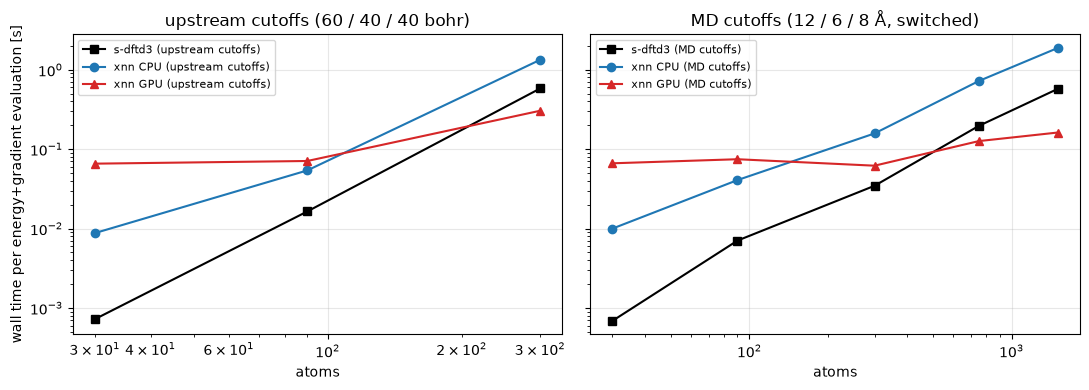

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
N = [r["N"] for r in timings]
for a, tag, keys in [(ax[0], "upstream cutoffs (60 / 40 / 40 bohr)", ["s-dftd3 (upstream cutoffs)", "xnn CPU (upstream cutoffs)", "xnn GPU (upstream cutoffs)"]),
                     (ax[1], "MD cutoffs (12 / 6 / 8 Å, switched)", ["s-dftd3 (MD cutoffs)", "xnn CPU (MD cutoffs)", "xnn GPU (MD cutoffs)"])]:
    for key, style in zip(keys, ["ks-", "C0o-", "C3^-"]):
        pts = [(r["N"], r[key]) for r in timings if key in r]
        if pts:
            a.loglog(*zip(*pts), style, label=key)
    a.set_title(tag); a.set_xlabel("atoms"); a.grid(alpha=0.3); a.legend(fontsize=8)
ax[0].set_ylabel("wall time per energy+gradient evaluation [s]")
plt.tight_layout(); plt.show()


**Reading the timings.** With the upstream cutoffs every atom of a liquid has thousands
of neighbors inside 40 bohr, so the three-body sum -- $O(N\,n_{\rm nb}^2)$ triples -- dominates
both codes, and the GPU is what makes it affordable. With MD-style cutoffs the triple count
drops by orders of magnitude and the D3 term costs a small fraction of a typical MLIP
evaluation. The `|dE|` column confirms that the shorter cutoffs are still evaluated
identically by both codes; what they change is the physics one chooses to include, and
the switching windows (an xnn extension) keep that choice smooth for dynamics.


## 3. D3 on top of a short-range MLIP, through every channel

The wrapper adds the dispersion energy to any registered model: here an (untrained, but
structurally complete) MACE for water with a 4.5 Å neighborhood. The wrapper's cutoff is
the D3 pair cutoff, the core sees only its own edges, and the same object deploys through
the eager `AtomicGraph` path, the ASE calculator, and the TorchScript export with its two
tensor ABIs (whole-system and LAMMPS pair-style). Forces and stress carry the D3 term.


In [6]:
cfg = from_dict({"model": {"name": "mace", "cutoff": 4.5, "n_interactions": 2, "n_rbf": 8, "n_features": 16,
                           "extra": {"species": [1, 8], "l_max": 2, "atomic_energies": [-13.6, -2041.0],
                                     "dispersion": {"name": "d3", **md_style, "s9": 1.0}}}})
torch.manual_seed(0)
model = build_model(cfg.model).eval()
print(type(model).__name__, "around", type(model.model).__name__, "| neighbor-list cutoff", model.cutoff, "Å | core cutoff", model.model.cutoff, "Å")

box = water_cluster(20); box.set_cell([8.4, 8.4, 8.4]); box.pbc = True
graph = structure_to_graph({"pos": box.positions, "atomic_numbers": box.numbers, "cell": box.cell[:], "pbc": box.pbc}, model.cutoff)
eager = ForceStressOutput(model, compute_stress=True)(graph)
print(f"eager:       E = {float(eager['energy']):.6f} eV = E_sr {float(eager['energy_sr']):.6f} + E_disp {float(eager['energy_disp']):.6f}  "
      f"(2-body {float(eager['energy_2body']):.4f}, ATM {float(eager['energy_3body']):+.4f});  CN range {float(eager['coordination_numbers'].min()):.2f}..{float(eager['coordination_numbers'].max()):.2f}")

box.calc = XNNCalculator(ForceStressOutput(model, compute_stress=True), cutoff=model.cutoff)
print(f"ASE:         E = {box.get_potential_energy():.6f} eV, |F| max {np.abs(box.get_forces()).max():.4f} eV/Å, stress xx {box.get_stress()[0]:.6f} eV/Å³")

scripted = torch.jit.script(TorchScriptPotential(model, model.cutoff).eval())
ts = scripted(torch.tensor(box.positions), torch.tensor(box.numbers), torch.tensor(box.cell[:]), torch.tensor(box.pbc))
print(f"TorchScript: E = {float(ts['energy']):.6f} eV, |dF| vs eager {float((ts['forces'] - eager['forces'].detach()).abs().max()):.1e}, "
      f"|dstress| {float((ts['stress'] - eager['stress'][0].detach()).abs().max()):.1e}")
ei, cs = build_neighbor_list(torch.tensor(box.positions), model.cutoff, torch.tensor(box.cell[:]), torch.tensor(box.pbc))
pair = scripted.forward_lammps(torch.tensor(box.positions), ei, cs, torch.tensor(box.numbers), torch.tensor(box.cell[:]))
print(f"pair-style:  E = {float(pair['energy']):.6f} eV (the LAMMPS ABI, neighbor list supplied; {ei.shape[1]} edges at {model.cutoff} Å)")


D3Dispersion around MACE | neighbor-list cutoff 12.0 Å | core cutoff 4.5 Å


eager:       E = -41346.047549 eV = E_sr -41344.128236 + E_disp -1.919312  (2-body -1.9935, ATM +0.0742);  CN range 0.99..2.02


ASE:         E = -41346.047549 eV, |F| max 5.8047 eV/Å, stress xx -0.156413 eV/Å³


TorchScript: E = -41346.047549 eV, |dF| vs eager 1.5e-14, |dstress| 7.5e-16


pair-style:  E = -41346.047549 eV (the LAMMPS ABI, neighbor list supplied; 44416 edges at 12.0 Å)


## Summary

* **Accuracy.** xnn reproduces `s-dftd3` to ~1e-17 Eh in dispersion energies, gradients and
  virials, for the S22 complexes and for crystals; the dispersion contributions to
  interaction energies agree to better than 1e-12 kcal/mol.
* **Speed.** The Fortran reference is fast for small molecules; xnn's vectorized evaluation
  scales to condensed-phase sizes on the GPU, and with MD-style cutoffs the D3 term is cheap
  next to the MLIP it supplements. The three-body term with the upstream 40 bohr cutoff is
  the one setting that should not be carried into large-scale MD.
* **Deployment.** One `DFTD3` module serves training and every deploy channel; a D3-corrected
  MACE exports to a self-contained TorchScript artifact with both tensor ABIs.
